<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [1]:
!pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-gpu openpyxl datasets langchain-community ragatouille umap-learn

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


In [8]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
# Новый импорт FAISS
from langchain_community.vectorstores import FAISS

# Новый импорт Document
try:
    from langchain_core.documents import Document as LangchainDocument
except ImportError:
    from langchain.schema import Document as LangchainDocument

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig


#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки

# pd.set_option("display.max_colwidth", None)

## Загрузка данных (4 балла)

In [12]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

# gdown.download(url, output, quiet=False)

data = pd.read_csv('data.csv')

In [13]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [14]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [15]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

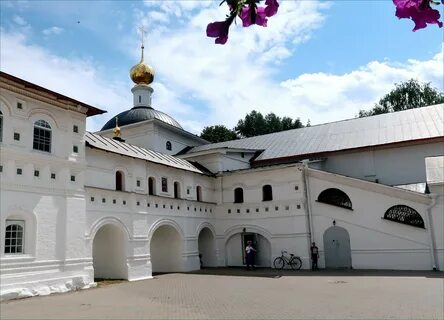

In [16]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [18]:
# TF-IDF based outlier detection (one cell)
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import zscore
import numpy as np
df = data.copy()
# Требование: в df есть столбец "description"
texts = df["description"].fillna("").astype(str).str.strip()
mask_nonempty = texts.str.len() > 0
corpus = texts[mask_nonempty].tolist()
idx_map = np.where(mask_nonempty)[0]  # соответствие индексов в df

# 1) Vectorize (1-2 grams). Настройки можно подогнать.
vec = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95,
                      token_pattern=r"(?u)\b\w+\b", lowercase=True)
X = vec.fit_transform(corpus)  # shape (n_docs, n_features)
feature_names = np.array(vec.get_feature_names_out())

# 2) idf для всех фич
idf = vec.idf_  # shape (n_features,)

# 3) Для каждого документа вычислим "mean_idf" — среднее idf по токенам, взвешенное по TF-IDF
#    это даёт меру того, насколько документ состоит из редких (высокое mean_idf) или очень общих (низкое mean_idf) слов.
#    Используем sparse матричные операции.
tfidf = X.tocsr()
# суммарный взвешенный idf = sum_j tfidf_ij * idf_j
weighted_idf_sum = tfidf.dot(idf)            # shape (n_docs,)
# нормировка по сумме tfidf для документа (чтобы учесть длину и интенсивность)
tfidf_sum = tfidf.sum(axis=1).A1             # shape (n_docs,)
# защититься от нулей
tfidf_sum_safe = np.where(tfidf_sum == 0, 1e-9, tfidf_sum)
mean_idf_per_doc = weighted_idf_sum / tfidf_sum_safe

# 4) Маркируем выбросы по z-score (по умолчанию |z| > 2)
z = zscore(mean_idf_per_doc)
outlier_mask = np.abs(z) > 2.0

# 5) Для удобства извлечём топ-5 термов по TF-IDF для каждого документа (показывает, что в тексте доминирует)
def top_terms_from_row(row_csr, topk=5):
    if row_csr.nnz == 0:
        return []
    row = row_csr.toarray().ravel()
    top_idx = np.argsort(row)[-topk:][::-1]
    terms = [feature_names[i] for i in top_idx if row[i] > 0]
    return terms

top_terms = [top_terms_from_row(tfidf[i], topk=5) for i in range(tfidf.shape[0])]

# 6) Записываем обратно в исходный df
df["_tfidf_mean_idf"] = np.nan
df["_tfidf_mean_idf"].iloc[idx_map] = mean_idf_per_doc
df["_tfidf_z"] = np.nan
df["_tfidf_z"].iloc[idx_map] = z
df["top_terms"] = np.nan
for pos, doc_idx in enumerate(idx_map):
    df.at[doc_idx, "top_terms"] = top_terms[pos]
df["tfidf_outlier"] = False
df.loc[idx_map, "tfidf_outlier"] = outlier_mask

# 7) Вывод краткой статистики и примеров (5 подозрительных + 5 случайных не подозрительных)
n_out = int(df["tfidf_outlier"].sum())
print(f"Total documents: {len(df)}, detected tfidf_outliers: {n_out}")

print("\nПримеры подозрительных (top 5):")
display(df[df["tfidf_outlier"]].sort_values("_tfidf_z", ascending=False).head(5)[["title","city","_tfidf_mean_idf","_tfidf_z","top_terms","description"]])



/tmp/ipykernel_171511/3215408124.py:50: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["_tfidf_mean_idf"].iloc[idx_map] = mean_idf_per_doc
/tmp/ipykernel_171511/3215408124.py:50: SettingWithCopyWarning: 
A value is trying to be set on a co

ValueError: Must have equal len keys and value when setting with an iterable

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain.embeddings import HuggingFaceEmbeddings
from ragatouille import RAGPretrainedModel

# ------------------------------------------------------
# 1) Берём очищенные описания достопримечательностей
#     df_clean — твой датафрейм после фильтрации TF-IDF
# ------------------------------------------------------

texts = df_clean["description"].fillna("").tolist()

# ------------------------------------------------------
# 2) Делаем чанкование текстов
# ------------------------------------------------------
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=80,
    separators=["\n\n", "\n", ".", " ", ""]
)

documents = []
for t in texts:
    for chunk in splitter.split_text(t):
        documents.append({"text": chunk})

# ------------------------------------------------------
# 3) Строим эмбеддинги (можно любую sentence-transformers модель)
# ------------------------------------------------------
emb_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# ------------------------------------------------------
# 4) Строим FAISS-векторную базу
# ------------------------------------------------------
faiss_index = FAISS.from_texts(
    texts=[doc["text"] for doc in documents],
    embedding=emb_model
)

# ------------------------------------------------------
# 5) Подключаем ragatouille для ранжирования
#     (M2-BERT_RANKER — дефолтный предобученный)
# ------------------------------------------------------
ranker = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")

def retrieve(query, k=10):
    """Поиск + rerank через ragatouille."""
    # Первичный поиск
    docs = faiss_index.similarity_search(query, k=30)
    passages = [d.page_content for d in docs]

    # Переупорядочивание
    reranked = ranker.rerank(query=query, documents=passages, k=k)

    # Возвращаем топ-k уже отсортированных
    return reranked

# ------------------------------------------------------
# 6) Пример запроса
# ------------------------------------------------------
query = "архитектура Санкт-Петербурга в стиле барокко"
top_docs = retrieve(query, k=5)

top_docs
# your code here

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [ ]:
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import numpy as np

# эмбеддинги для визуализации
embs = faiss_index.index.reconstruct_n(0, faiss_index.index.ntotal)
embs = np.array(embs)

# PCA
pca = PCA(n_components=2)
pca_2d = pca.fit_transform(embs)

plt.figure(figsize=(7,7))
plt.scatter(pca_2d[:,0], pca_2d[:,1], s=4)
plt.title("PCA")
plt.show()

# UMAP
um = umap.UMAP(n_components=2, random_state=42)
um_2d = um.fit_transform(embs)

plt.figure(figsize=(7,7))
plt.scatter(um_2d[:,0], um_2d[:,1], s=4)
plt.title("UMAP")
plt.show()


# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

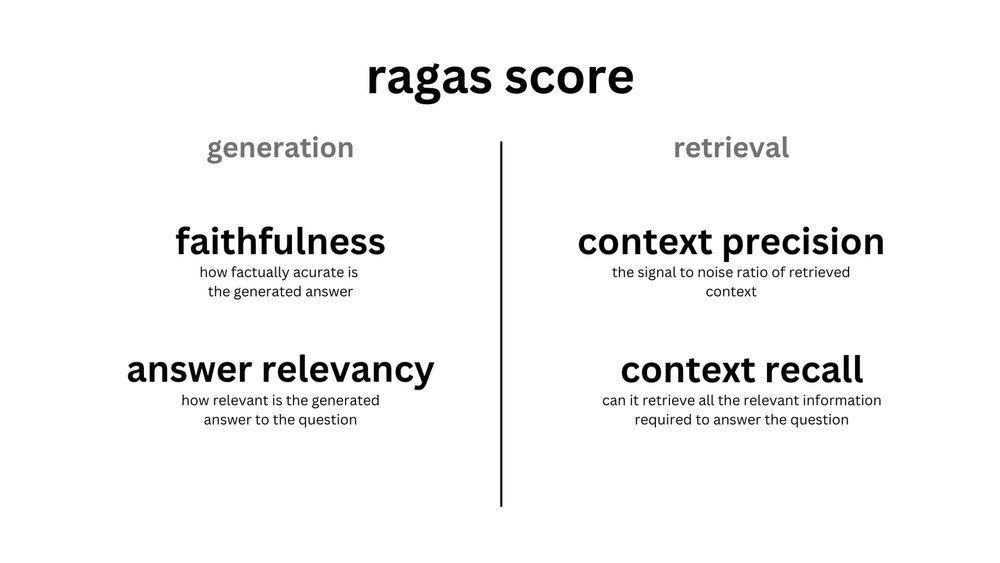

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [ ]:
import random
from typing import List, Dict

def data_preprocess(data: List[Dict], sample_size: int = 100, seed: int = 42):
    random.seed(seed)
    # стратифицированная выборка по городу и названию места
    grouped = {}
    for row in data:
        key = (row['city'], row['name'])
        grouped.setdefault(key, []).append(row)

    samples = []
    for group in grouped.values():
        n = max(1, int(sample_size / len(grouped)))
        samples.extend(random.sample(group, min(len(group), n)))

    # если меньше sample_size, дополняем случайными
    if len(samples) < sample_size:
        remaining = [row for row in data if row not in samples]
        samples.extend(random.sample(remaining, sample_size - len(samples)))

    return samples

def answer_relevancy(predictions: List[Dict], references: List[Dict]):
    results = []
    for pred, ref in zip(predictions, references):
        question = pred.get('question', '')
        answer = pred.get('answer', '')
        context = ref.get('description', '')
        relevancy_score = 1.0 if answer.strip().lower() in context.lower() else 0.0
        results.append({
            'question': question,
            'predicted_answer': answer,
            'reference_context': context,
            'relevancy': relevancy_score
        })
    return results


# Протестируйте ваш RAG (3 балла)

In [ ]:
# Пример тестирования RAG на случайных 100 образцах

samples = data_preprocess(data, sample_size=100)

predictions = []
for sample in samples:
    query = sample['description']  # можно сгенерировать question через LLM
    # инференс через RAG
    answer = rag_model.predict(query, top_k=5)  # примерный вызов, зависит от вашей реализации
    predictions.append({
        'question': query,
        'answer': answer
    })

relevancy_results = answer_relevancy(predictions, samples)

# Считаем среднюю релевантность
avg_relevancy = sum(r['relevancy'] for r in relevancy_results) / len(relevancy_results)
print(f"Average relevancy on 100 samples: {avg_relevancy:.2f}")


# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def retrieval_accuracy(query_embeddings, doc_embeddings, true_indices, top_k=5):
    """
    Простая метрика для retrieval-части: вычисляем процент правильных документов,
    попавших в top_k ближайших по косинусной схожести.

    query_embeddings: np.array, shape=(n_queries, dim)
    doc_embeddings: np.array, shape=(n_docs, dim)
    true_indices: list of lists, где true_indices[i] — индексы релевантных документов для i-го запроса
    top_k: int, сколько ближайших документов учитывать
    """
    correct = 0
    for i, q_emb in enumerate(query_embeddings):
        sims = cosine_similarity([q_emb], doc_embeddings)[0]
        top_docs = np.argsort(sims)[::-1][:top_k]
        if any(idx in top_docs for idx in true_indices[i]):
            correct += 1
    return correct / len(query_embeddings)
